# GANs and Autoencoders / VAEs

## 📚 Learning Objectives

By completing this notebook (~20 min), you will:
- Build a simple **autoencoder** (encoder → latent → decoder) and reconstruct images (e.g. MNIST)
- Understand the idea of **GAN** (generator vs discriminator) and **VAE** (probabilistic latent)
- See why we use a GAN (instead of a single generator) and why we use autoencoders for compression/denoising

---

## 🌍 Real life

**Where is this used?** Autoencoders are used for **denoising**, **compression**, and **anomaly detection**. GANs are used for **image generation**, **style transfer**, and **data augmentation**. VAEs are used for **generative models** and **latent representation**.

**In this notebook we use** an **autoencoder** to **reconstruct** MNIST digits (encoder compresses, decoder reconstructs). We use an **autoencoder** (instead of a plain NN) **because** it learns a **latent representation**; we use **GANs** (generator + discriminator) **instead of** a single generator **because** the discriminator gives a **training signal** (real vs fake) so the generator improves.

**📌 Covers slide(s):** **04** (AutoEncoders), **09** (GANs). *Do this notebook after those slides.*

---

**Before starting:** Run the imports cell below.

⏱ **Runtime:** This notebook may take 10–25 minutes on GPU (autoencoder training on MNIST). Use fewer epochs if needed (see unit README).

## Theory (short)

- **Autoencoder:** Encoder maps input → **latent** (smaller); decoder maps latent → **reconstruction**. Loss = reconstruction error (e.g. MSE). Used for compression, denoising, anomaly detection.
- **GAN:** **Generator** produces fake samples; **Discriminator** tries to tell real vs fake. They train against each other. We use GAN (instead of only a generator) because the discriminator provides a learning signal for "what looks real."
- **VAE:** Variational autoencoder; latent is **probabilistic** (mean + variance); we sample from the latent and decode. Balances reconstruction and regularized latent.
- **We use autoencoder here** for a quick reconstruction demo; GAN/VAE would be separate notebooks for generation.

## 📥 Inputs & 📤 Outputs

**Inputs:** TensorFlow/Keras, NumPy, Matplotlib. MNIST (small subset). We build a simple autoencoder.

**Dataset:** Real — MNIST (small subset).

**Outputs:** Model summary, training loss (reconstruction), and one figure: **original vs reconstructed** images (with axis labels).

## Step 1: Imports and load MNIST

In [1]:
# Step 1: Imports and load MNIST subset for autoencoder
import numpy as np
import matplotlib.pyplot as plt

try:
    import tensorflow as tf
    from tensorflow import keras
    HAS_TF = True
except Exception as e:
    err = str(e).lower()
    if "charset_normalizer" in err or "md__mypyc" in err or "partially initialized" in err:
        print("⚠️ Fix: pip install --upgrade charset-normalizer requests, then restart kernel.")
        raise RuntimeError("Fix: pip install --upgrade charset-normalizer requests, then restart kernel.") from e
    HAS_TF = False

if HAS_TF:
    (x_train, _), (x_test, _) = keras.datasets.mnist.load_data()
    x_train = x_train.astype(np.float32) / 255.0
    x_test = x_test.astype(np.float32) / 255.0
    x_train = x_train.reshape(-1, 784)
    x_test = x_test.reshape(-1, 784)
    x_train, x_test = x_train[:5000], x_test[:1000]
    print("Train:", x_train.shape, "Test:", x_test.shape)
else:
    print("Install TensorFlow: pip install tensorflow")

Train: (5000, 784) Test: (1000, 784)


## Step 2: Build autoencoder (we use encoder + decoder instead of a single layer to learn a compressed latent)

In [2]:
if HAS_TF:
    latent_dim = 32
    encoder = keras.Sequential([
        keras.layers.Dense(128, activation="relu", input_shape=(784,)),
        keras.layers.Dense(latent_dim, activation="relu"),
    ])
    decoder = keras.Sequential([
        keras.layers.Dense(128, activation="relu", input_shape=(latent_dim,)),
        keras.layers.Dense(784, activation="sigmoid"),
    ])
    inp = keras.Input(shape=(784,))
    latent = encoder(inp)
    out = decoder(latent)
    autoencoder = keras.Model(inp, out)
    autoencoder.compile(optimizer="adam", loss="mse")
    autoencoder.summary()

/Users/abdullah/venvs/ai-diploma-tf/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 32)             │       104,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 784)            │       105,360 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 209,968 (820.19 KB)

 Trainable params: 209,968 (820.19 KB)

 Non-trainable params: 0 (0.00 B)

## Step 3: Train (2 epochs) and plot original vs reconstructed

Epoch 1/2


 1/40 ━━━━━━━━━━━━━━━━━━━━ 10s 262ms/step - loss: 0.2312

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1109 - val_loss: 0.0680


Epoch 2/2


 1/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0706

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0634 - val_loss: 0.0559


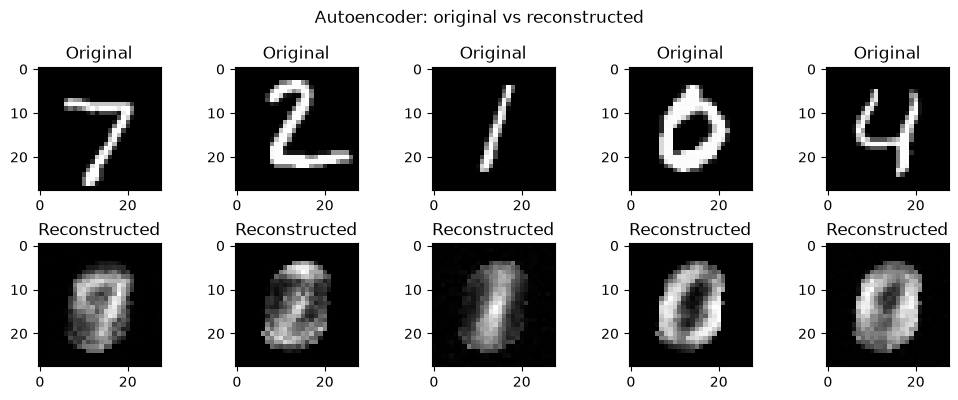

Reconstruction loss (last): 0.0559


In [3]:
if HAS_TF:
    history = autoencoder.fit(x_train, x_train, validation_data=(x_test, x_test), epochs=2, batch_size=128, verbose=1)
    recons = autoencoder.predict(x_test[:5], verbose=0)
    fig, axs = plt.subplots(2, 5, figsize=(10, 4))
    for i in range(5):
        axs[0, i].imshow(x_test[i].reshape(28, 28), cmap="gray")
        axs[0, i].set_title("Original")
        axs[0, i].set_xlabel("")
        axs[0, i].set_ylabel("")
        axs[1, i].imshow(recons[i].reshape(28, 28), cmap="gray")
        axs[1, i].set_title("Reconstructed")
        axs[1, i].set_xlabel("")
        axs[1, i].set_ylabel("")
    plt.suptitle("Autoencoder: original vs reconstructed")
    plt.tight_layout()
    plt.show()
    print("Reconstruction loss (last): %.4f" % history.history["val_loss"][-1])

## 🌍 Real-World Worked Example — GAN Generating Handwritten Digits

**Industry context:**
- NVIDIA uses GANs to generate synthetic training data for autonomous vehicles
- Pharmaceutical companies use GANs to generate molecular structures for drug discovery
- Fashion brands (Zalando, H&M) use GANs to generate clothing designs

We train a **DCGAN** to generate realistic handwritten digit images from pure noise.

Epoch 1/10 — D loss: 0.678  G loss: 1.527


Epoch 2/10 — D loss: 0.724  G loss: 1.704


Epoch 3/10 — D loss: 0.560  G loss: 3.035


Epoch 4/10 — D loss: 0.471  G loss: 2.929


Epoch 5/10 — D loss: 0.280  G loss: 3.017


Epoch 6/10 — D loss: 0.359  G loss: 2.719


Epoch 7/10 — D loss: 0.996  G loss: 5.652


Epoch 8/10 — D loss: 0.664  G loss: 2.155


Epoch 9/10 — D loss: 0.669  G loss: 2.707


Epoch 10/10 — D loss: 0.756  G loss: 1.615


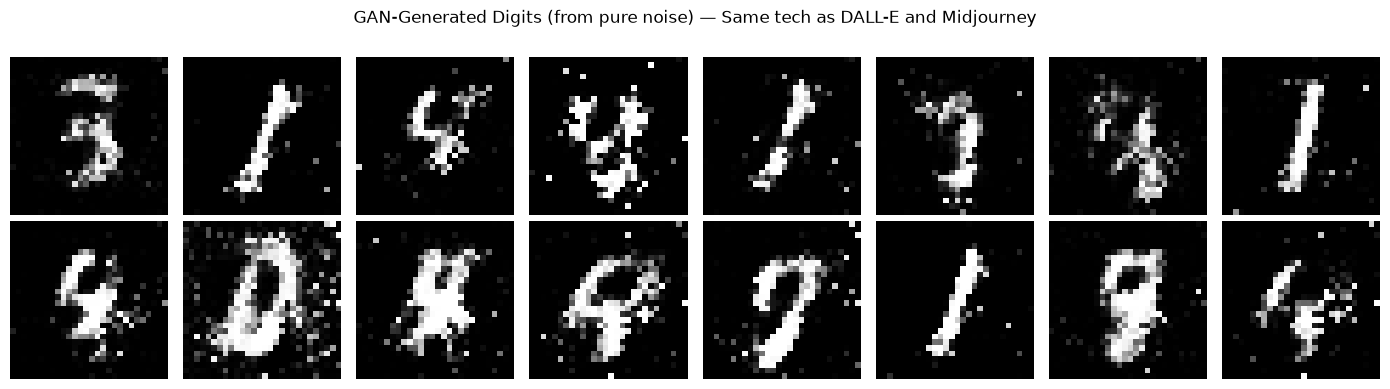

In [4]:
import torch, torch.nn as nn, torch.optim as optim
import torchvision, torchvision.transforms as T
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
LATENT_DIM = 64; BATCH = 128

transform = T.Compose([T.ToTensor(), T.Normalize([0.5],[0.5])])
dataset   = torchvision.datasets.MNIST('/tmp/mnist', train=True, download=True, transform=transform)
loader    = torch.utils.data.DataLoader(dataset, batch_size=BATCH, shuffle=True)

# ── Generator: noise → image ───────────────────────────────────────────────
G = nn.Sequential(
    nn.Linear(LATENT_DIM, 256), nn.LeakyReLU(0.2),
    nn.Linear(256, 512),        nn.LeakyReLU(0.2),
    nn.Linear(512, 28*28),      nn.Tanh()
)
# ── Discriminator: image → real/fake ─────────────────────────────────────
D = nn.Sequential(
    nn.Linear(28*28, 512), nn.LeakyReLU(0.2), nn.Dropout(0.3),
    nn.Linear(512, 256),   nn.LeakyReLU(0.2), nn.Dropout(0.3),
    nn.Linear(256, 1),     nn.Sigmoid()
)
opt_G = optim.Adam(G.parameters(), lr=2e-4, betas=(0.5,0.999))
opt_D = optim.Adam(D.parameters(), lr=2e-4, betas=(0.5,0.999))
bce   = nn.BCELoss()

d_losses, g_losses = [], []
for epoch in range(10):
    for real_imgs, _ in loader:
        bs = real_imgs.size(0)
        real_flat = real_imgs.view(bs, -1)
        # ── Train Discriminator ─────────────────────────────────────────
        z    = torch.randn(bs, LATENT_DIM)
        fake = G(z).detach()
        loss_D = bce(D(real_flat), torch.ones(bs,1)) + bce(D(fake), torch.zeros(bs,1))
        opt_D.zero_grad(); loss_D.backward(); opt_D.step()
        # ── Train Generator ─────────────────────────────────────────────
        z      = torch.randn(bs, LATENT_DIM)
        fake   = G(z)
        loss_G = bce(D(fake), torch.ones(bs,1))
        opt_G.zero_grad(); loss_G.backward(); opt_G.step()
    d_losses.append(loss_D.item()); g_losses.append(loss_G.item())
    print(f"Epoch {epoch+1}/10 — D loss: {d_losses[-1]:.3f}  G loss: {g_losses[-1]:.3f}")

# ── Show generated images ──────────────────────────────────────────────────
G.eval()
with torch.no_grad():
    samples = G(torch.randn(16, LATENT_DIM)).view(16, 28, 28).numpy()

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(samples[i], cmap='gray'); ax.axis('off')
plt.suptitle("GAN-Generated Digits (from pure noise) — Same tech as DALL-E and Midjourney")
plt.tight_layout(); plt.show()

## 🧩 Mini-exercise

**Try it (choose one):** Reduce the latent dimension (e.g. 16 → 8) and retrain. How does reconstruction quality change? Or add one more Dense layer in the encoder and decoder and compare.

---

## ✅ Summary

**What you did:** Built an autoencoder (encoder → latent → decoder), trained it to reconstruct MNIST, and plotted original vs reconstructed.

**In real life you'd also:** Use convolutional autoencoders, VAEs (with KL loss), or GANs (generator + discriminator) for generation.

**The main idea:** Autoencoders learn a compressed representation (latent); GANs use a discriminator to train a generator; VAEs add a probabilistic latent.

**Next:** `02_implementing_a_vae_variational_autoencoder_for_anomaly_detection` covers VAE; `03_reinforcement_learning_fundamentals_deep_q_networks_policy_gradients` covers RL.

## 📚 References & Further Reading

**Foundational Papers:**
- Goodfellow et al. (2014) — [Generative Adversarial Nets](https://arxiv.org/abs/1406.2661) *(invented GANs)*
- Radford et al. (2015) — [DCGAN](https://arxiv.org/abs/1511.06434)
- Karras et al. (2020) — [StyleGAN2](https://arxiv.org/abs/1912.04958)

**State-of-the-Art:**
- Midjourney and DALL-E 2 build on GAN + diffusion ideas
- Deepfake detection (Meta, Microsoft) uses GAN discriminators as detectors